# Milestone 1: Data Analysis from Artist perspective

> **Data source:** Use the already cleaned data files, specifically `cleaned_artists.csv` and `cleaned_artworks.csv` located under `data/`.


This notebook performs three data analyses mainly focused on artists.

## Analysis1: artist birth decade vs nationality

Goal: To explore the geographical distribution(nationality) of artists born each year.

Adjustment: Since there are very few artists born in some years, the statistics for each year have been expanded to include the 1910s (1911-1919: all are counted as the 1910s).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Read the cleaned artists data
df_clean = pd.read_csv("../../data/cleaned_artists.csv")


# Create a new column 'Decade' by flooring the 'BeginDate' to the nearest decade
df_clean['Decade'] = (df_clean['BeginDate'] // 10) * 10


# Top 15 Artist Nationalities
top_15_nationalities = df_clean['Nationality'].value_counts().head(15).index
df_top = df_clean[df_clean['Nationality'].isin(top_15_nationalities)]



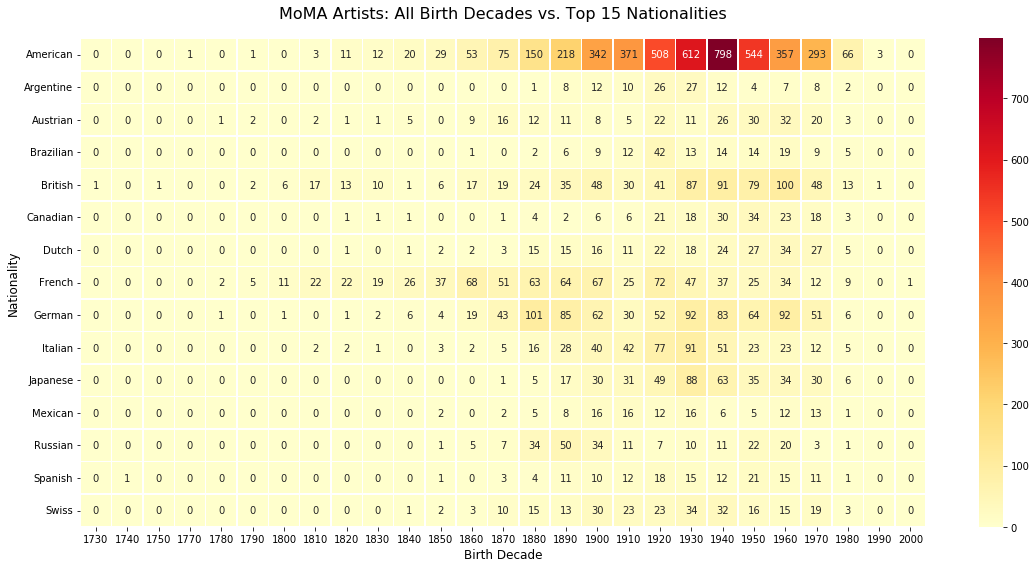

In [ ]:

# Get the count of artists (each Decade and each Nationality)
pivot_df = df_top.groupby(['Decade', 'Nationality']).size().unstack(fill_value=0)

# Heatmap
plt.figure(figsize=(16, 8))
# X: Decade; Y: Nationality; Color: Count
sns.heatmap(pivot_df.T, cmap='YlOrRd', linewidths=.5, annot=True, fmt='g')
plt.title('MoMA Artists: All Birth Decades vs. Top 15 Nationalities', fontsize=16, pad=20)
plt.xlabel('Birth Decade', fontsize=12)
plt.ylabel('Nationality', fontsize=12)
plt.tight_layout()
plt.show()

<Figure size 1152x504 with 0 Axes>

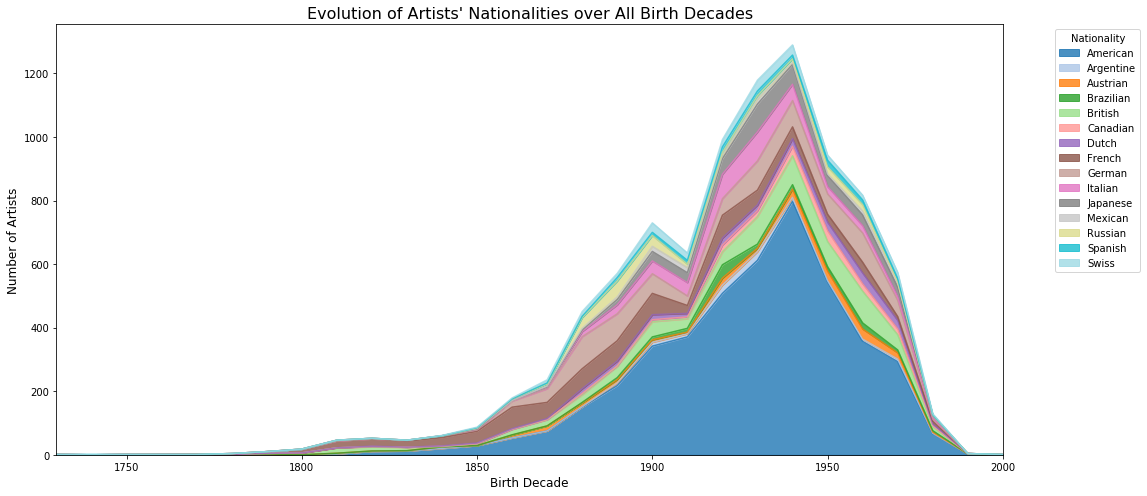

In [ ]:
# Same data: an area chart to show the evolution of each nationality(area size — number of artists) 
plt.figure(figsize=(16, 7))
pivot_df.plot(kind='area', stacked=True, colormap='tab20', alpha=0.8, figsize=(16, 7))
plt.title('Evolution of Artists\' Nationalities over All Birth Decades', fontsize=16)
plt.xlabel('Birth Decade', fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.legend(title='Nationality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Attempt: To display the distribution of artists from the 1940s on a world map

import plotly.express as px

# Read the cleaned artists data
df = pd.read_csv('../../data/cleaned_artists.csv')

# 1940 <= BeginDate <= 1949
df_1940s = df[(df['BeginDate'] >= 1940) & (df['BeginDate'] <= 1949)].copy()

# Get the count of artists by nationality (1940s)
nat_counts = df_1940s['Nationality'].value_counts().reset_index()
nat_counts.columns = ['Nationality', 'Count']


# Create a mapping(dictionary: nationality -> country name)
nationality_to_country = {
    'American': 'United States',
    'French': 'France',
    'German': 'Germany',
    'British': 'United Kingdom',
    'Japanese': 'Japan',
    'Italian': 'Italy',
    'Swiss': 'Switzerland',
    'Spanish': 'Spain',
    'Russian': 'Russia',
    'Dutch': 'Netherlands',
    'Canadian': 'Canada',
    'Mexican': 'Mexico',
    'Brazilian': 'Brazil',
    'Argentine': 'Argentina',
    'Chilean': 'Chile',
    'Colombian': 'Colombia',
    'Venezuelan': 'Venezuela',
    'Austrian': 'Austria',
    'Belgian': 'Belgium',
    'Danish': 'Denmark',
    'Finnish': 'Finland',
    'Swedish': 'Sweden',
    'Norwegian': 'Norway',
    'Polish': 'Poland',
    'Czech': 'Czech Republic',
    'Hungarian': 'Hungary',
    'Romanian': 'Romania',
    'Greek': 'Greece',
    'Turkish': 'Turkey',
    'Israeli': 'Israel',
    'Indian': 'India',
    'Chinese': 'China',
    'Korean': 'South Korea',
    'Taiwanese': 'Taiwan',
    'Australian': 'Australia',
    'New Zealander': 'New Zealand',
    'South African': 'South Africa',
    'Cuban': 'Cuba',
    'Peruvian': 'Peru',
    'Irish': 'Ireland',
    'Portuguese': 'Portugal',
    'Yugoslav': 'Serbia'
}


nat_counts['Country'] = nat_counts['Nationality'].map(nationality_to_country)

# Check for any unmapped nationalities
unmapped = nat_counts[nat_counts['Country'].isna()]
if not unmapped.empty and unmapped['Count'].max() > 5:
    print("The following nationalities are not mapped and will not be displayed:")
    print(unmapped.head())

# Drop
nat_counts_clean = nat_counts.dropna(subset=['Country'])


# Create Choropleth Map
fig = px.choropleth(
    nat_counts_clean,
    locations="Country",           
    locationmode='country names',
    color="Count",                 
    hover_name="Country",         
    hover_data={"Nationality": True, "Count": True, "Country": False},
    color_continuous_scale=px.colors.sequential.YlOrRd, # yellow-orange-red
    title="Global Distribution of MoMA Artists Born in the 1940s",
)

fig.update_layout(
    geo=dict(
        showframe=False,       
        showcoastlines=True,
        projection_type='natural earth' # also could be:'natural earth'
    ),
    title_x=0.5,
    title_font_size=20
)

fig.show()

## Analysis2: Artworks Classification of Artist vs. Artworks created time

Goal: To explore the change/evolution of an artist's artworks classification throughout his/her life.

Adjustment: Due to the large number of artists, in order to observe the evolution trend of each artist's own artworks classification, only the top 10 artists in terms of the number of artworks created are selected here.

In [3]:
# Read data
df_art = pd.read_csv('../../data/cleaned_artworks.csv')

df_art['Date'] = pd.to_numeric(df_art['Date'], errors='coerce')
df_art_clean = df_art.dropna(subset=['Date', 'Artist', 'Classification']).copy()

# Top 10 artists by number of artworks
top_10_artists = df_art_clean['Artist'].value_counts().head(10).index
df_top_art = df_art_clean[df_art_clean['Artist'].isin(top_10_artists)]


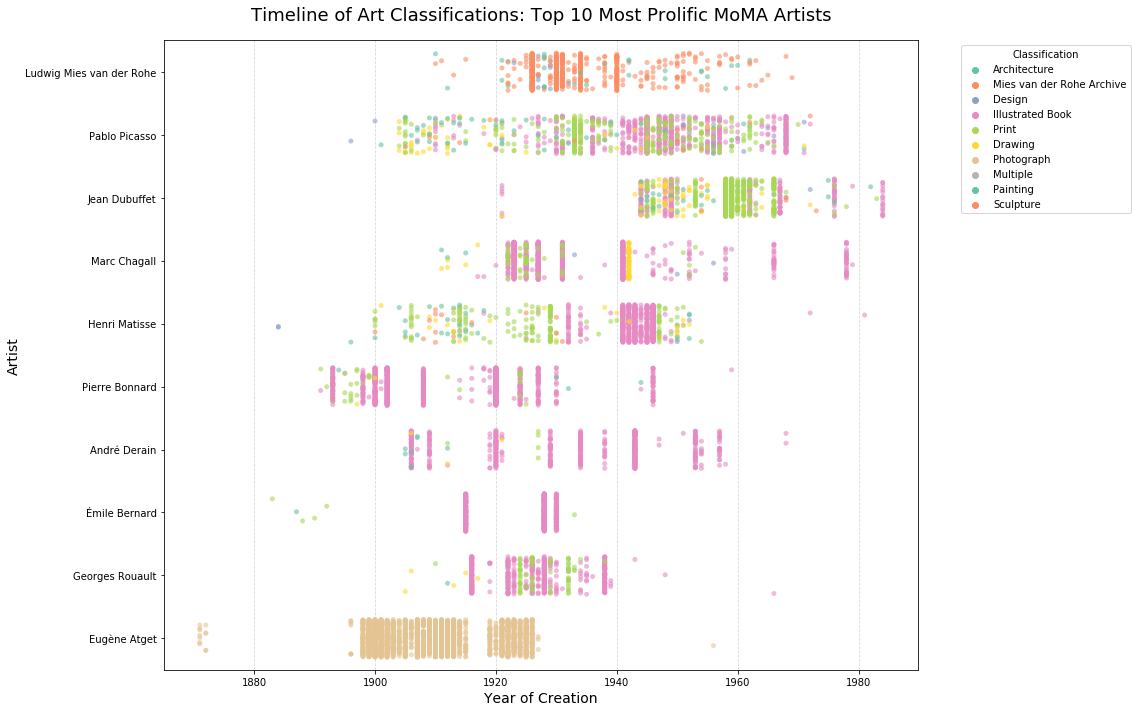

In [5]:

# Create Strip Plot
plt.figure(figsize=(16, 10))

sns.stripplot(
    data=df_top_art, 
    x='Date', 
    y='Artist', 
    hue='Classification', 
    jitter=0.3, 
    alpha=0.6, 
    size=5, 
    palette='Set2'
)

plt.title('Timeline of Art Classifications: Top 10 Most Prolific MoMA Artists', fontsize=18, pad=20)
plt.xlabel('Year of Creation', fontsize=14)
plt.ylabel('Artist', fontsize=14)

plt.legend(title='Classification', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Analysis 3: The age of each artist vs artworks they created then

Goal: To Explore the relationship between an artist's creative peak/down and their age.

Adjustment: Due to the large number of artists, only the top 20 artists in terms of the number of artworks created are selected here.

In [6]:
# Read data
df_artworks = pd.read_csv('../../data/cleaned_artworks.csv')
df_artists = pd.read_csv('../../data/cleaned_artists.csv')

# Join two csv files (by ConstituentID)
df_artworks['ConstituentID'] = df_artworks['ConstituentID'].astype(str).str.strip()
df_artists['ConstituentID'] = df_artists['ConstituentID'].astype(str).str.strip()
df_merged = pd.merge(
    df_artworks, 
    df_artists[['ConstituentID', 'BeginDate']], 
    on='ConstituentID', 
    how='left'
)


df_merged['Date'] = pd.to_numeric(df_merged['Date'], errors='coerce')
df_merged['BeginDate'] = pd.to_numeric(df_merged['BeginDate'], errors='coerce')

# Compute the age when each artist created their arts
df_merged['Age_at_Creation'] = df_merged['Date'] - df_merged['BeginDate']

# filter some unreasonable age data
df_valid_age = df_merged[(df_merged['Age_at_Creation'] >= 10) & (df_merged['Age_at_Creation'] <= 110)].copy()


# df_valid_age.to_csv('../../data/cleaned_artworks_with_age.csv', index=False)
# print("Compute the age when each artist created their arts, Save as 'cleaned_artworks_with_age.csv'")

# Top 20 artists by number of artworks
top_20_artists = df_valid_age['Artist'].value_counts().head(20).index
df_top20 = df_valid_age[df_valid_age['Artist'].isin(top_20_artists)]

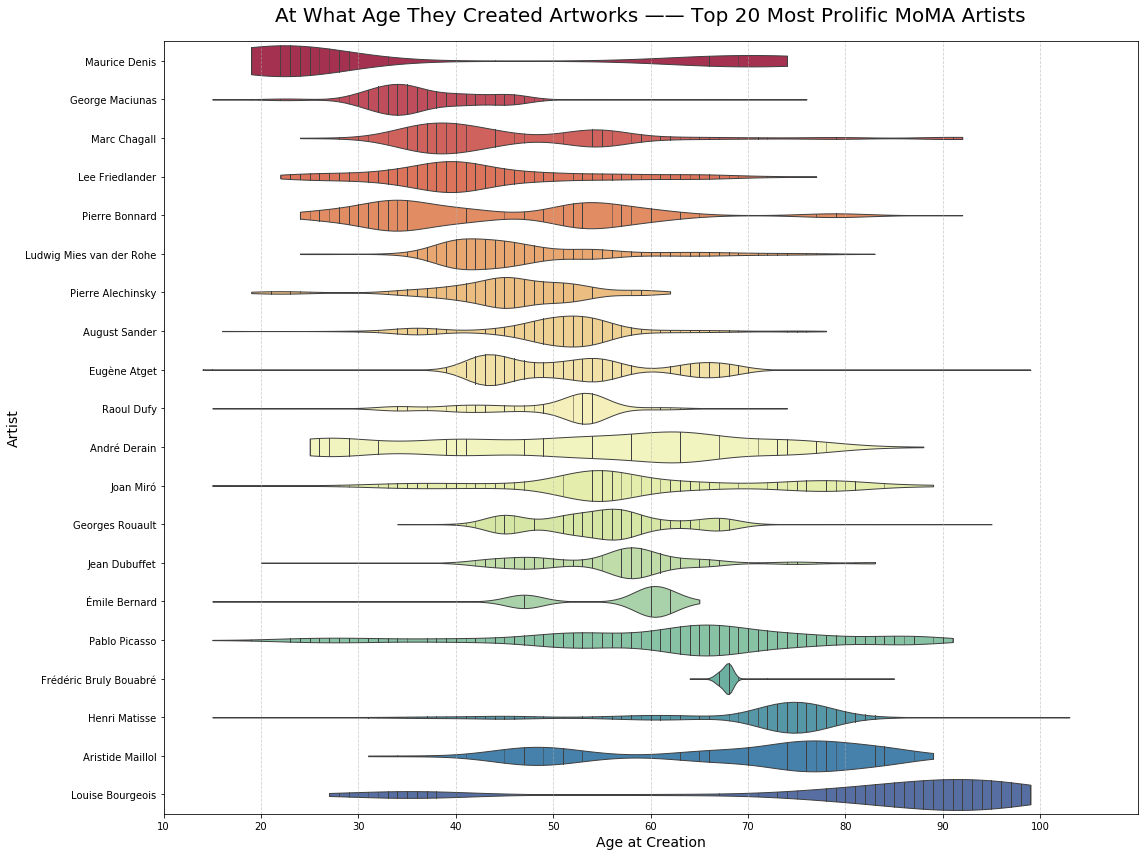

In [7]:

plt.figure(figsize=(16, 12))
order = df_top20.groupby('Artist')['Age_at_Creation'].median().sort_values().index

# Create Violin Plot
sns.violinplot(
    data=df_top20, 
    x='Age_at_Creation', 
    y='Artist', 
    order=order,
    scale='width',      
    inner='stick',     
    palette='Spectral',
    linewidth=1,
    alpha=0.7,
    cut=0
)
plt.title('At What Age They Created Artworks —— Top 20 Most Prolific MoMA Artists', fontsize=20, pad=20)
plt.xlabel('Age at Creation', fontsize=14)
plt.ylabel('Artist', fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.xticks(range(10, 110, 10))
plt.xlim(10, 110)

plt.tight_layout()
plt.show()